## Data Understanding and Exploratory Data Analysis (EDA)

Explore the dataset sufficiently to understand its structure, distributions, relationships and potential quality
problems. EDA should inform later preprocessing decisions rather than being treated as a collection of
unrelated plots.

### Dataset size and shape: number of rows and columns

In [3]:
%pip install pandas numpy openpyxl matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "../Data/default of credit card clients.xlsx"
df = pd.read_excel(file_path, header=1)

df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [13]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 30000
Number of columns: 25


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [10]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

### Interpretation for Dataset size and shape: number of rows and columns
- 30,0000 rows and 25 columns
- Columns : identifier | customer personal profile | credit and payment information | bill and payment amounts
- target variable : **default payment next month** 

## Variable types: numerical, categorical, ordinal, datetime, identifiers and target variable

In [15]:
df.dtypes

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

In [17]:
df.nunique()

ID                            30000
LIMIT_BAL                        81
SEX                               2
EDUCATION                         7
MARRIAGE                          4
AGE                              56
PAY_0                            11
PAY_2                            11
PAY_3                            11
PAY_4                            11
PAY_5                            10
PAY_6                            10
BILL_AMT1                     22723
BILL_AMT2                     22346
BILL_AMT3                     22026
BILL_AMT4                     21548
BILL_AMT5                     21010
BILL_AMT6                     20604
PAY_AMT1                       7943
PAY_AMT2                       7899
PAY_AMT3                       7518
PAY_AMT4                       6937
PAY_AMT5                       6897
PAY_AMT6                       6939
default payment next month        2
dtype: int64

| Variable Type| Variables |
| -------------| -------   |
| Identifier   | 'ID'      |
| Numerical    | 'LIMIT_BAL', 'AGE', 'BILL_AMT1' - 'BILL_AMT6','PAY_AMT1' - 'PAY_AMT6' |
| Categorical  | 'SEX', 'MARRIAGE'|
| Ordinal      | 'Education', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6' |
| DateTime     | None |
| Target       | 'default payment next month' |

## Interpretation for Variable types: numerical, categorical, ordinal, datetime, identifiers and target variable

- Although all the features are integer types, they do not all represent numerical measurements.
- Some of the features are categorical or ordinal such as SEX, MARRIAGE, Education, and the repayment status.
-  During the preprocessing stage, Those features will be treated according to their meaning.

## Statistical summaries: mean, median, mode where meaningful, standard deviation, minimum, maximum, quartiles, range, IQR, cardinality and category frequencies

In [20]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [ ]:
print("Median: ")
print(df.median(numeric_only=True))

print("\nMode: ")
print(df.mode().iloc[0])

Median:
ID                             15000.5
LIMIT_BAL                     140000.0
SEX                                2.0
EDUCATION                          2.0
MARRIAGE                           2.0
AGE                               34.0
PAY_0                              0.0
PAY_2                              0.0
PAY_3                              0.0
PAY_4                              0.0
PAY_5                              0.0
PAY_6                              0.0
BILL_AMT1                      22381.5
BILL_AMT2                      21200.0
BILL_AMT3                      20088.5
BILL_AMT4                      19052.0
BILL_AMT5                      18104.5
BILL_AMT6                      17071.0
PAY_AMT1                        2100.0
PAY_AMT2                        2009.0
PAY_AMT3                        1800.0
PAY_AMT4                        1500.0
PAY_AMT5                        1500.0
PAY_AMT6                        1500.0
default payment next month         0.0
dtype: float64

M

In [33]:
print("Standard Deviation: ")
print(df.std(numeric_only=True))

print("\nRange: ")
print(df.max(numeric_only=True) - df.min(numeric_only=True))

print("\nIQR: ")
print(df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True))


Standard Deviation: 
ID                              8660.398374
LIMIT_BAL                     129747.661567
SEX                                0.489129
EDUCATION                          0.790349
MARRIAGE                           0.521970
AGE                                9.217904
PAY_0                              1.123802
PAY_2                              1.197186
PAY_3                              1.196868
PAY_4                              1.169139
PAY_5                              1.133187
PAY_6                              1.149988
BILL_AMT1                      73635.860576
BILL_AMT2                      71173.768783
BILL_AMT3                      69349.387427
BILL_AMT4                      64332.856134
BILL_AMT5                      60797.155770
BILL_AMT6                      59554.107537
PAY_AMT1                       16563.280354
PAY_AMT2                       23040.870402
PAY_AMT3                       17606.961470
PAY_AMT4                       15666.159744
PAY_AMT5   

In [38]:
categorical_columns = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for column in categorical_columns:
    print(df[column].value_counts().sort_index())

SEX
1    11888
2    18112
Name: count, dtype: int64
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        

## Interpretation for Statistical summaries: mean, median, mode where meaningful, standard deviation, minimum, maximum, quartiles, range, IQR, cardinality and category frequencies

- Variables have different ranges and levels of variation as shown in the statistical summaries.  
- Variables such as age have much lower ranges than the following variables credit limit, bill amounts, and payment amounts.
- The amount of variation differs between variables as shown in the standard deviation.
- During the later preprocessing stage, those differences will be considered.
- Some categories are much more common than others as shown in the category frequencies.
- The PAY_ variables are mainly concentrated around 0, -1, and -2, while the EDUCATION and Marriage variables contain a small number of less frequent categories.
- During the data cleaning stage, the less frequent and unusual values will be investigated.

## Missingness summary: counts and percentages by variable

In [50]:
pd.DataFrame({ "Missing Count" : df.isna().sum(), "Missing Percentage" : df.isna().mean()})

,Missing Count,Missing Percentage
ID,0,0.0
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


## Interpretation for Missingness summary: counts and percentages by variable

- All variables have no missing values.
- A missing count of 0 and a missing count of 0% were found across all variables.
- During the cleaning stage, there will be no missing value that will need handling.

## Visual analysis: appropriate histograms, bar charts, box plots, scatter plots, target distributions and correlation heatmaps

## Histograms

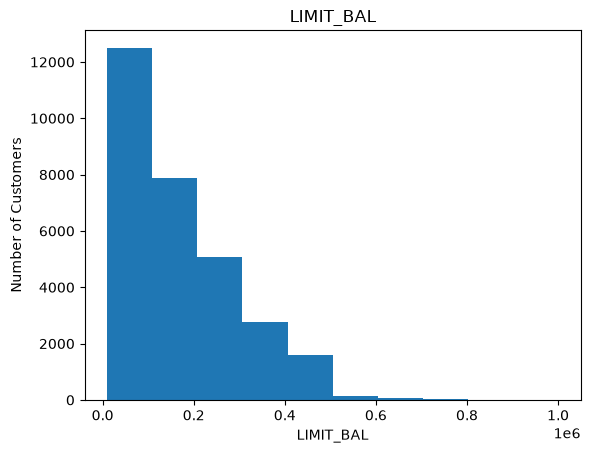

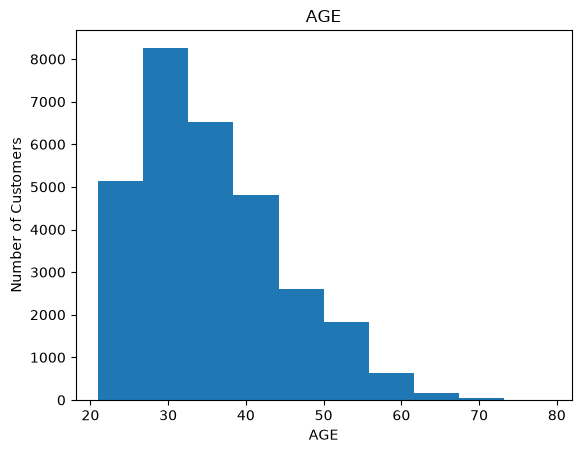

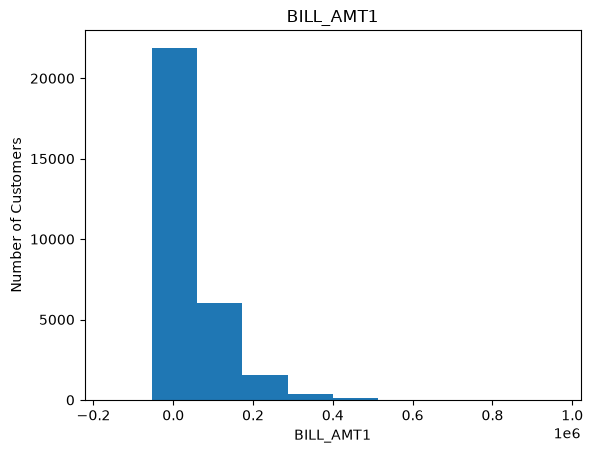

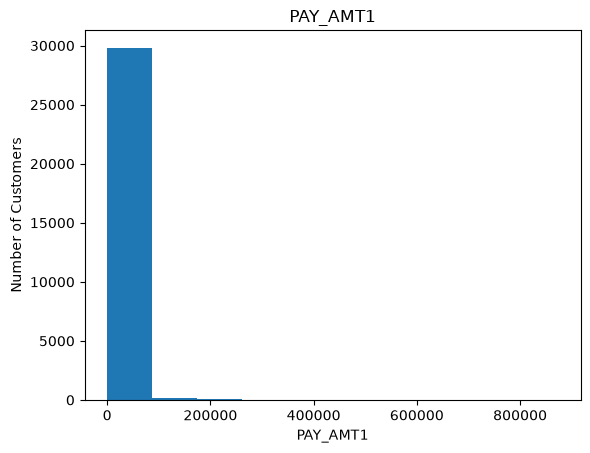

In [59]:
for column in ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]:
    df[column].plot.hist()
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.show()


## Bar Plots

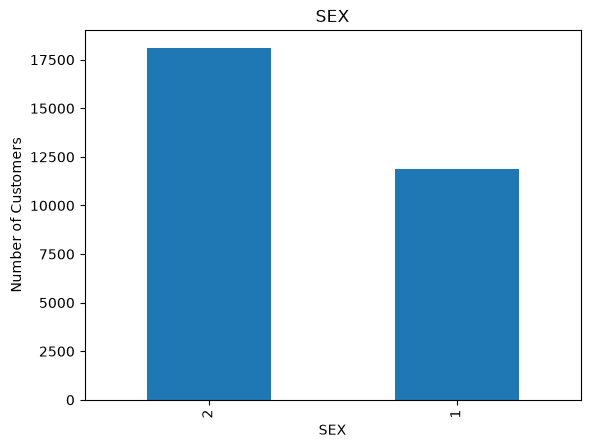

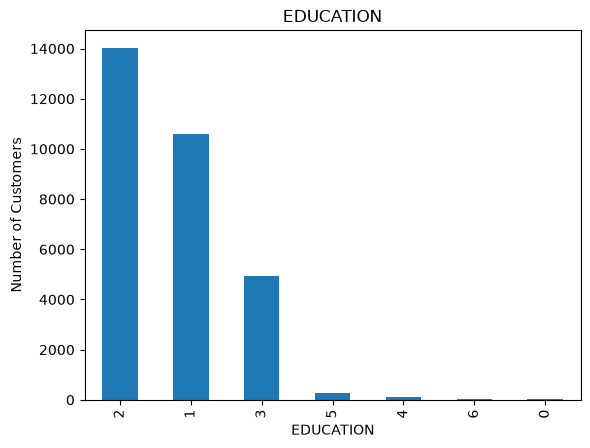

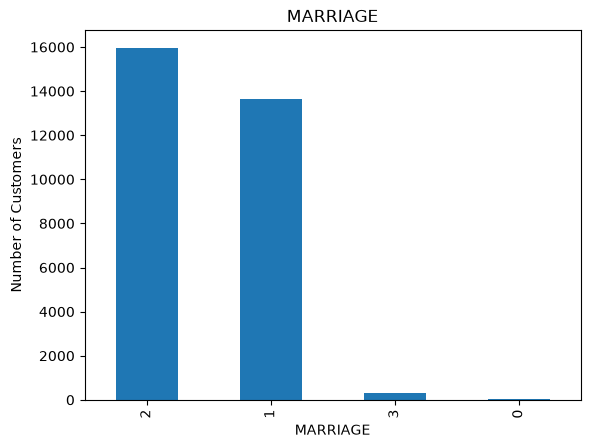

In [60]:
for column in ["SEX", "EDUCATION", "MARRIAGE"]:
    df[column].value_counts().plot.bar()
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.show()


## Target Distribution

In [ ]:
print("Counts:")
print(df["default payment next month"].value_counts().sort_index())

print("\nPercentages:")
print(df["default payment next month"].value_counts(normalize=True).sort_index() * 100)

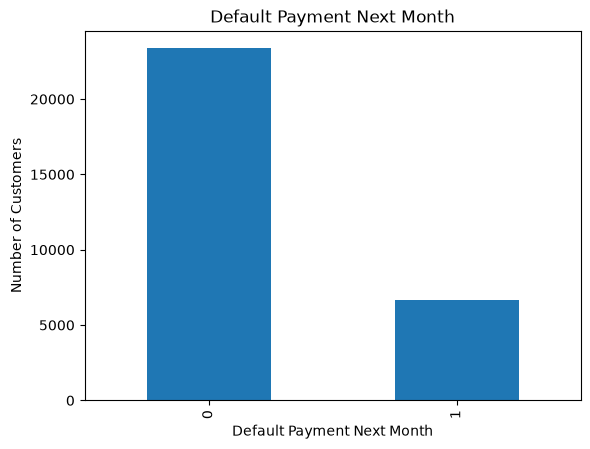

In [90]:
df["default payment next month"].value_counts().sort_index().plot.bar()

plt.title("Default Payment Next Month")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Customers")
plt.show()

## Box Plots

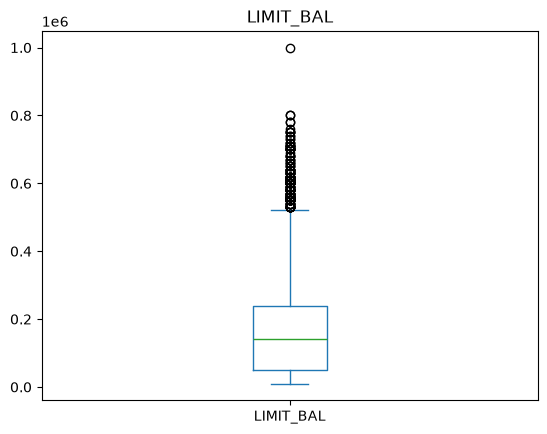

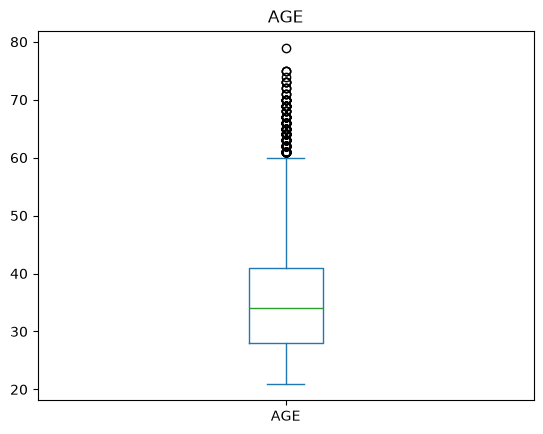

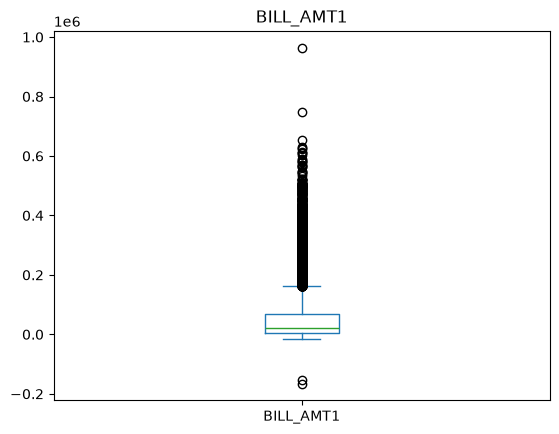

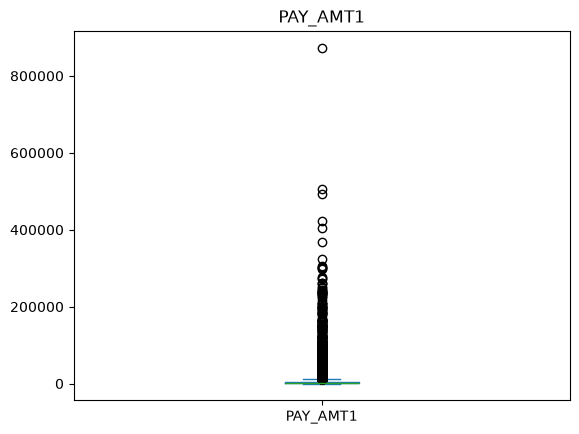

In [89]:
for column in ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]:
    df[column].plot.box()
    plt.title(column)
    plt.show()


## Scatter Plots

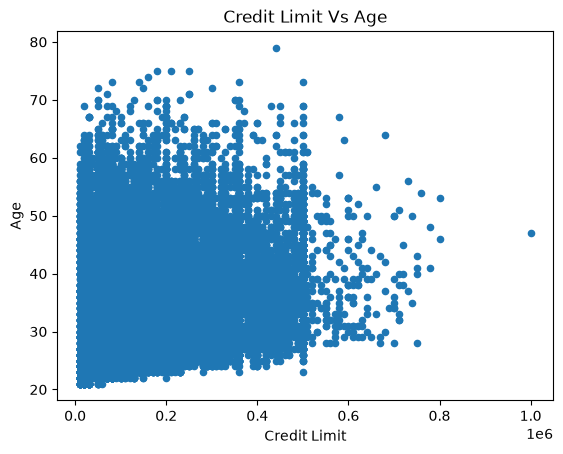

In [61]:
df.plot.scatter(x="LIMIT_BAL", y="AGE")
plt.title("Credit Limit Vs Age")
plt.xlabel("Credit Limit")
plt.ylabel("Age")
plt.show()

## Correlation HeatMap

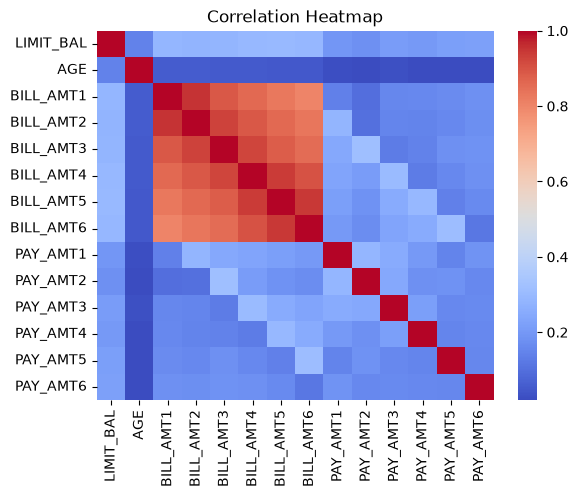

In [ ]:
numerical_columns = ["LIMIT_BAL", "AGE", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6", "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

corr = df[numerical_columns].corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Interpretation for Visual analysis: appropriate histograms, bar charts, box plots, scatter plots, target distributions and correlation heatmaps

- To examine distributions, category frequencies, potential outliers and relationships within the dataset visual analysis was used.
- The numerical variables have different distributions and levels of spread as shown in the histogram.
- Age is more concentrated within a smaller range while the credit limit, bill amounts and payment amounts have wider and more uneven distributions.
- Some categories are more common than others as shown in the bar charts.
- EDUCATION and MARRIAGE variables contain categories with much lower frequencies while there are more customers in category 2 for SEX.
- To highlight potential outliers the box plots were used in variables such as credit limit, bill amounts and payment amounts.
- Most customers didn't default with 23,364 customers (77.88%) in the non-default class compared with 6,636 customers (22.12%) who defaulted as the target distribution shows.
- A wide spread of points were shown between credit limit and age in the scatter plot with no strong relationship between them.
- The payment amount variables generally show weaker correlations, while the bill amount variables showed stronger positive correlations  across different months as the  correlation heatmap shows.
- During the data cleaning, preprocessing and feature selection stages, we will consider these findings.